# DensePolarNet-Robust v4: 3-Seed Ensemble (identical settings)

This notebook keeps the **same architecture, augmentations, preprocessing, loss, optimizer, EMA, TTA, and validation protocol** as the robust single-seed notebook, and adds a **3-seed ensemble** on top.

## What stays identical
- **DenseNet-161** backbone
- small-image stem
- polar branch + radial statistics branch
- astrophysical preprocessing (`asinh` stretch + robust normalization)
- the same augmentation family
- focal loss, AdamW, cosine LR, EMA, D4 TTA
- **90:10 stratified split only inside the training folders**
- official `test_*` folders remain untouched

## What changes
We train the **same model/config** with three random seeds:

- `42`
- `1337`
- `2029`

Then we average the **validation probabilities** and **test probabilities** across the three trained models.
The decision threshold is chosen **only on the ensembled validation probabilities**, then applied once to the test set.


In [1]:
# # OPTIONAL: run only in a fresh Kaggle session if PyTorch does not support the P100.
# !pip uninstall -y -q torch torchvision torchaudio
# !pip install -q --no-cache-dir --force-reinstall \
#     torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 \
#     --index-url https://download.pytorch.org/whl/cu118


In [2]:
import torch, torchvision

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("arch list:", torch.cuda.get_arch_list())

use_cuda = torch.cuda.is_available() and ("sm_60" in torch.cuda.get_arch_list())
device = torch.device("cuda" if use_cuda else "cpu")
print("Using device:", device)


torch: 2.4.1+cu118
torch cuda: 11.8
cuda available: True
gpu: Tesla P100-PCIE-16GB
arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']
Using device: cuda


In [3]:
import os
import gc
import math
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, precision_recall_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision.models import (
    densenet121, densenet161,
    DenseNet121_Weights, DenseNet161_Weights
)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [4]:
class CFG:
    # model
    MODEL_NAME = "densenet161"
    PRETRAINED = False
    SMALL_IMAGE_STEM = True
    USE_POLAR_BRANCH = True
    USE_RADIAL_BRANCH = True
    MEMORY_EFFICIENT = True

    # split / ensemble
    SPLIT_SEED = 42
    ENSEMBLE_SEEDS = [42, 1337, 2029]

    # data
    IMG_SIZE = 64
    VALID_SIZE = 0.10
    NUM_WORKERS = 2

    # augmentation
    P_FLIP = 0.5
    MAX_SHIFT = 3
    P_BAND_DROPOUT = 0.20
    P_NOISE = 0.30
    NOISE_STD_MAX = 0.03
    P_GAIN_JITTER = 0.50
    GAIN_JITTER = 0.12

    # training
    EPOCHS = 18
    BATCH_SIZE = 20
    LR = 2e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5
    AMP = True
    CLIP_GRAD_NORM = 1.0

    # imbalance
    FOCAL_ALPHA = 0.80
    FOCAL_GAMMA = 2.0

    # EMA
    USE_EMA = True
    EMA_DECAY = 0.999

    # inference
    USE_TTA = True
    TTA_D4 = True

    # threshold search on validation
    THRESH_GRID = np.linspace(0.05, 0.95, 181)

    # outputs
    SAVE_DIR = Path("/kaggle/working/densepolar_ensemble")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

CFG.__dict__


mappingproxy({'__module__': '__main__',
              'MODEL_NAME': 'densenet161',
              'PRETRAINED': False,
              'SMALL_IMAGE_STEM': True,
              'USE_POLAR_BRANCH': True,
              'USE_RADIAL_BRANCH': True,
              'MEMORY_EFFICIENT': True,
              'SPLIT_SEED': 42,
              'ENSEMBLE_SEEDS': [42, 1337, 2029],
              'IMG_SIZE': 64,
              'VALID_SIZE': 0.1,
              'NUM_WORKERS': 2,
              'P_FLIP': 0.5,
              'MAX_SHIFT': 3,
              'P_BAND_DROPOUT': 0.2,
              'P_NOISE': 0.3,
              'NOISE_STD_MAX': 0.03,
              'P_GAIN_JITTER': 0.5,
              'GAIN_JITTER': 0.12,
              'EPOCHS': 18,
              'BATCH_SIZE': 20,
              'LR': 0.0002,
              'WEIGHT_DECAY': 0.0001,
              'PATIENCE': 5,
              'AMP': True,
              'CLIP_GRAD_NORM': 1.0,
              'FOCAL_ALPHA': 0.8,
              'FOCAL_GAMMA': 2.0,
              'USE_EMA'

In [5]:
def find_dataset_root():
    needed = ["train_lenses", "train_nonlenses", "test_lenses", "test_nonlenses"]

    explicit_candidates = [
        Path("/kaggle/input/datasets/arushhh/dataset-task-v"),
        Path("/kaggle/input/dataset-task-v"),
    ]
    for root in explicit_candidates:
        if root.exists() and all((root / x).exists() for x in needed):
            return root

    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir() and all((p / x).exists() for x in needed):
            return p

    raise FileNotFoundError("Could not find dataset root under /kaggle/input.")

CFG.ROOT = find_dataset_root()
print("Using dataset root:", CFG.ROOT)


Using dataset root: /kaggle/input/datasets/arushhh/dataset-task-v


In [6]:
def build_dataframe(root):
    rows = []
    mapping = {
        "train_lenses": (1, "train"),
        "train_nonlenses": (0, "train"),
        "test_lenses": (1, "test"),
        "test_nonlenses": (0, "test"),
    }

    for folder, (label, split) in mapping.items():
        folder_path = Path(root) / folder
        files = sorted(folder_path.glob("*.npy"))
        rows.extend([{
            "path": str(f),
            "label": label,
            "split": split,
            "folder": folder
        } for f in files])

    return pd.DataFrame(rows)

df = build_dataframe(CFG.ROOT)
print(df["folder"].value_counts())
display(df.head())

train_df = df[df["split"] == "train"].reset_index(drop=True).copy()
test_df  = df[df["split"] == "test"].reset_index(drop=True).copy()

train_idx, valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=CFG.VALID_SIZE,
    stratify=train_df["label"].values,
    random_state=CFG.SPLIT_SEED
)

trn_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[valid_idx].reset_index(drop=True)

print("Train split size:", len(trn_df), " | lens fraction:", trn_df["label"].mean())
print("Valid split size:", len(val_df), " | lens fraction:", val_df["label"].mean())
print("Held-out test size:", len(test_df), " | lens fraction:", test_df["label"].mean())


folder
train_nonlenses    28675
test_nonlenses     19455
train_lenses        1730
test_lenses          195
Name: count, dtype: int64


,path,label,split,folder
0,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
1,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
2,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
3,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
4,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses


Train split size: 27364  | lens fraction: 0.05689957608536764
Valid split size: 3041  | lens fraction: 0.056889181190397896
Held-out test size: 19650  | lens fraction: 0.009923664122137405


torch.Size([3, 64, 64]) torch.float32 tensor(0.)


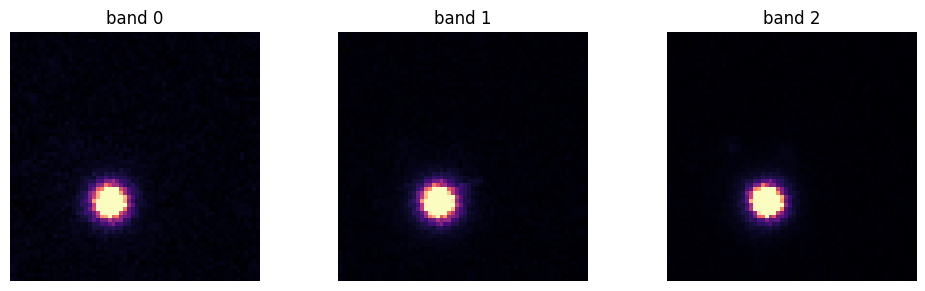

In [7]:
def load_npy(path):
    x = np.load(path)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape} for {path}")

    if x.shape[0] == 3:
        pass
    elif x.shape[-1] == 3:
        x = np.transpose(x, (2, 0, 1))
    else:
        raise ValueError(f"Expected channel dimension of 3, got shape {x.shape} for {path}")

    return x

def astrophysical_stretch(x):
    x = np.maximum(x, 0.0)
    out = np.zeros_like(x, dtype=np.float32)

    for c in range(x.shape[0]):
        scale = np.percentile(x[c], 99.5)
        scale = max(scale, 1e-6)
        y = np.arcsinh(x[c] / scale)
        y = y / max(np.arcsinh(1.0), 1e-6)
        # robust post-normalization
        p1, p99 = np.percentile(y, 1.0), np.percentile(y, 99.0)
        if p99 > p1:
            y = (y - p1) / (p99 - p1)
        y = np.clip(y, 0.0, 1.0)
        out[c] = y.astype(np.float32)

    return out

def random_rot90(x):
    k = np.random.randint(0, 4)
    return np.rot90(x, k, axes=(1, 2)).copy()

def random_flip(x):
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, :, ::-1].copy()
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, ::-1, :].copy()
    return x

def random_shift(x, max_shift=3):
    if max_shift <= 0:
        return x
    dx = np.random.randint(-max_shift, max_shift + 1)
    dy = np.random.randint(-max_shift, max_shift + 1)
    pad = max_shift
    xp = np.pad(x, ((0, 0), (pad, pad), (pad, pad)), mode="reflect")
    h, w = x.shape[1:]
    sx = pad + dx
    sy = pad + dy
    return xp[:, sy:sy+h, sx:sx+w].copy()

def random_gain_jitter(x):
    if np.random.rand() < CFG.P_GAIN_JITTER:
        gains = np.random.uniform(
            1.0 - CFG.GAIN_JITTER,
            1.0 + CFG.GAIN_JITTER,
            size=(x.shape[0], 1, 1)
        ).astype(np.float32)
        x = x * gains
    return x

def random_band_dropout(x):
    if np.random.rand() < CFG.P_BAND_DROPOUT:
        c = np.random.randint(0, x.shape[0])
        x = x.copy()
        x[c] = 0.0
    return x

def random_noise(x):
    if np.random.rand() < CFG.P_NOISE:
        sigma = np.random.uniform(0.0, CFG.NOISE_STD_MAX)
        x = x + np.random.normal(0.0, sigma, size=x.shape).astype(np.float32)
    return np.clip(x, 0.0, 1.0)

class LensDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_npy(row.path)

        if self.augment:
            x = random_rot90(x)
            x = random_flip(x)
            x = random_shift(x, CFG.MAX_SHIFT)

        x = astrophysical_stretch(x)

        if self.augment:
            x = random_gain_jitter(x)
            x = random_band_dropout(x)
            x = random_noise(x)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row.label, dtype=torch.float32)
        return x, y

sample_x, sample_y = LensDataset(trn_df, augment=True)[0]
print(sample_x.shape, sample_x.dtype, sample_y)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(sample_x[i].numpy(), cmap="magma")
    axes[i].set_title(f"band {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [8]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loaders(seed):
    train_labels = trn_df["label"].values
    class_counts = np.bincount(train_labels.astype(int))
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels.astype(int)]

    sampler_gen = torch.Generator()
    sampler_gen.manual_seed(seed)

    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_gen
    )

    train_ds = LensDataset(trn_df, augment=True)
    valid_ds = LensDataset(val_df, augment=False)
    test_ds  = LensDataset(test_df, augment=False)

    loader_gen = torch.Generator()
    loader_gen.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=loader_gen,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    return train_loader, valid_loader, test_loader, class_counts

_, _, _, class_counts = make_loaders(CFG.ENSEMBLE_SEEDS[0])
print("class_counts [nonlens, lens]:", class_counts)


class_counts [nonlens, lens]: [25807  1557]


In [9]:
def d4_transforms(x):
    outs = []
    for k in range(4):
        r = torch.rot90(x, k=k, dims=(-2, -1))
        outs.append(r)
        outs.append(torch.flip(r, dims=(-1,)))
    return outs

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.80, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()

class PolarTransform(nn.Module):
    def __init__(self, radial_bins=32, angular_bins=64):
        super().__init__()
        r = torch.linspace(0, 1, radial_bins)
        theta = torch.linspace(0, 2 * math.pi, angular_bins)
        rr, tt = torch.meshgrid(r, theta, indexing="ij")
        x = rr * torch.cos(tt)
        y = rr * torch.sin(tt)
        grid = torch.stack([x, y], dim=-1)
        self.register_buffer("base_grid", grid)

    def forward(self, x):
        b = x.shape[0]
        grid = self.base_grid.unsqueeze(0).repeat(b, 1, 1, 1)
        polar = F.grid_sample(
            x, grid, mode="bilinear", padding_mode="zeros", align_corners=True
        )
        return polar

class PolarConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1):
        super().__init__()
        self.k = k
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        pad = self.k // 2
        # theta dimension is periodic; radius dimension is not.
        x = F.pad(x, (pad, pad, 0, 0), mode="circular")
        x = F.pad(x, (0, 0, pad, pad), mode="replicate")
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class FusionGate(nn.Module):
    def __init__(self, dim, reduction=8):
        super().__init__()
        hidden = max(dim // reduction, 32)
        self.gate = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.gate(x)

class DensePolarNetRobust(nn.Module):
    def __init__(self, model_name="densenet161", pretrained=False, small_image_stem=True,
                 use_polar_branch=True, use_radial_branch=True, memory_efficient=True):
        super().__init__()
        self.use_polar_branch = use_polar_branch
        self.use_radial_branch = use_radial_branch

        if model_name == "densenet121":
            weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet121(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet121(weights=None, memory_efficient=memory_efficient)
        elif model_name == "densenet161":
            weights = DenseNet161_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet161(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet161(weights=None, memory_efficient=memory_efficient)
        else:
            raise ValueError("model_name must be 'densenet121' or 'densenet161'")

        dense_dim = self.backbone.classifier.in_features

        if small_image_stem:
            old = self.backbone.features.conv0
            self.backbone.features.conv0 = nn.Conv2d(
                3, old.out_channels, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.features.pool0 = nn.Identity()

        self.backbone.classifier = nn.Identity()

        polar_dim = 0
        radial_dim = 0

        if self.use_polar_branch:
            self.polar = PolarTransform(radial_bins=32, angular_bins=64)
            self.polar_cnn = nn.Sequential(
                PolarConvBNAct(3, 32, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(32, 64, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(64, 128, 3),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            polar_dim = 128

        if self.use_radial_branch:
            # mean + std over theta -> 6 radial channels total for 3-band input
            self.radial_head = nn.Sequential(
                nn.Conv1d(6, 32, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool1d(1)
            )
            radial_dim = 64

        fused_dim = dense_dim + polar_dim + radial_dim
        self.fusion_gate = FusionGate(fused_dim, reduction=8)

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        feats = []

        dense_feat = self.backbone(x)
        feats.append(dense_feat)

        if self.use_polar_branch:
            polar = self.polar(x)
            polar_feat = self.polar_cnn(polar).flatten(1)
            feats.append(polar_feat)

            if self.use_radial_branch:
                radial_mean = polar.mean(dim=-1)
                radial_std = polar.std(dim=-1, unbiased=False)
                radial = torch.cat([radial_mean, radial_std], dim=1)
                radial_feat = self.radial_head(radial).flatten(1)
                feats.append(radial_feat)

        fused = torch.cat(feats, dim=1)
        fused = self.fusion_gate(fused)
        logit = self.head(fused).squeeze(1)
        return logit

model = DensePolarNetRobust(
    model_name=CFG.MODEL_NAME,
    pretrained=CFG.PRETRAINED,
    small_image_stem=CFG.SMALL_IMAGE_STEM,
    use_polar_branch=CFG.USE_POLAR_BRANCH,
    use_radial_branch=CFG.USE_RADIAL_BRANCH,
    memory_efficient=CFG.MEMORY_EFFICIENT
).to(device)

dummy = torch.randn(2, 3, 64, 64).to(device)
with torch.inference_mode():
    out = model(dummy)
print("output shape:", out.shape)
print("n params:", round(sum(p.numel() for p in model.parameters()) / 1e6, 2), "M")


output shape: torch.Size([2])
n params: 28.62 M


In [10]:
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        ema_state = self.ema.state_dict()
        model_state = model.state_dict()

        for k, v in ema_state.items():
            mv = model_state[k].detach()
            if torch.is_floating_point(v):
                v.mul_(self.decay).add_(mv, alpha=1.0 - self.decay)
            else:
                v.copy_(mv)

def build_model():
    model = DensePolarNetRobust(
        model_name=CFG.MODEL_NAME,
        pretrained=CFG.PRETRAINED,
        small_image_stem=CFG.SMALL_IMAGE_STEM,
        use_polar_branch=CFG.USE_POLAR_BRANCH,
        use_radial_branch=CFG.USE_RADIAL_BRANCH,
        memory_efficient=CFG.MEMORY_EFFICIENT,
    ).to(device)
    return model

def run_epoch(model, loader, criterion, optimizer=None, scaler=None, ema=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.CLIP_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)
        else:
            with torch.inference_mode():
                with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                    logits = model(x)
                    loss = criterion(logits, y)

        losses.append(loss.item())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

        del x, y, logits, loss

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    auc = roc_auc_score(all_targets, all_probs)
    return float(np.mean(losses)), float(auc), all_targets, all_probs

@torch.inference_mode()
def predict_loader(model, loader, use_tta=True):
    model.eval()
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        if use_tta and CFG.TTA_D4:
            preds = []
            for xt in d4_transforms(x):
                with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                    logits = model(xt)
                preds.append(torch.sigmoid(logits))
            probs = torch.stack(preds, dim=0).mean(dim=0)
        else:
            with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                logits = model(x)
            probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y.numpy())

        del x, y, probs
        if device.type == "cuda":
            torch.cuda.empty_cache()

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_probs

def train_one_seed(seed):
    print("=" * 80)
    print(f"Training seed {seed}")
    print("=" * 80)

    seed_everything(seed)
    train_loader, valid_loader, test_loader, _ = make_loaders(seed)

    model = build_model()
    criterion = BinaryFocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)
    scaler = torch.amp.GradScaler(device.type, enabled=(CFG.AMP and device.type == "cuda"))
    ema = ModelEMA(model, decay=CFG.EMA_DECAY) if CFG.USE_EMA else None

    best_auc = -np.inf
    best_state = None
    best_epoch = 0
    history = []

    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()

        train_loss, train_auc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler, ema=ema
        )

        eval_model = ema.ema if ema is not None else model
        valid_loss, valid_auc, _, _ = run_epoch(
            eval_model, valid_loader, criterion, optimizer=None, scaler=None, ema=None
        )

        scheduler.step()

        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_auc": train_auc,
            "valid_loss": valid_loss,
            "valid_auc": valid_auc,
            "lr": optimizer.param_groups[0]["lr"]
        })

        if valid_auc > best_auc:
            best_auc = valid_auc
            best_epoch = epoch
            best_state = copy.deepcopy(eval_model.state_dict())
            ckpt_path = CFG.SAVE_DIR / f"best_densepolar_robust_seed_{seed}.pt"
            torch.save(best_state, ckpt_path)

        dt = time.time() - t0
        print(
            f"Seed {seed} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_auc={train_auc:.4f} | "
            f"valid_loss={valid_loss:.4f} valid_auc={valid_auc:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | {dt:.1f}s"
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

        if epoch - best_epoch >= CFG.PATIENCE:
            print(
                f"Early stopping for seed {seed} at epoch {epoch}. "
                f"Best epoch was {best_epoch} with valid AUC={best_auc:.4f}"
            )
            break

    best_model = build_model()
    best_model.load_state_dict(best_state)
    best_model.eval()

    val_targets, val_probs = predict_loader(best_model, valid_loader, use_tta=CFG.USE_TTA)
    test_targets, test_probs = predict_loader(best_model, test_loader, use_tta=CFG.USE_TTA)

    history_df = pd.DataFrame(history)
    history_df.to_csv(CFG.SAVE_DIR / f"history_seed_{seed}.csv", index=False)

    summary = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_valid_auc_during_training": best_auc,
        "tta_valid_auc": roc_auc_score(val_targets, val_probs),
        "tta_test_auc": roc_auc_score(test_targets, test_probs),
    }

    return {
        "seed": seed,
        "model": best_model,
        "history": history_df,
        "summary": summary,
        "val_targets": val_targets,
        "val_probs": val_probs,
        "test_targets": test_targets,
        "test_probs": test_probs,
    }


Training seed 42


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Seed 42 | Epoch 01 | train_loss=0.0286 train_auc=0.9468 | valid_loss=0.0417 valid_auc=0.8925 | lr=1.98e-04 | 506.2s


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Seed 42 | Epoch 02 | train_loss=0.0227 train_auc=0.9674 | valid_loss=0.0826 valid_auc=0.9279 | lr=1.94e-04 | 500.1s


...

Seed 2029 | Epoch 17 | train_loss=0.0084 train_auc=0.9942 | valid_loss=0.0090 valid_auc=0.9915 | lr=1.52e-06 | 483.8s


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Seed 2029 | Epoch 18 | train_loss=0.0084 train_auc=0.9943 | valid_loss=0.0090 valid_auc=0.9913 | lr=0.00e+00 | 484.2s
Early stopping for seed 2029 at epoch 18. Best epoch was 13 with valid AUC=0.9926


,seed,best_epoch,best_valid_auc_during_training,tta_valid_auc,tta_test_auc
0,42,17,0.993911,0.993903,0.990269
1,1337,18,0.993102,0.993808,0.991073
2,2029,13,0.992618,0.993297,0.989437


,seed,epoch,train_loss,train_auc,valid_loss,valid_auc,lr
0,42,1,0.028575,0.946808,0.041655,0.892454,0.000198
1,42,2,0.022738,0.967376,0.082601,0.927862,0.000194
2,42,3,0.019227,0.975202,0.050764,0.811479,0.000187
3,42,4,0.018623,0.976352,0.024186,0.968417,0.000177
4,42,5,0.016585,0.982011,0.011362,0.988424,0.000164


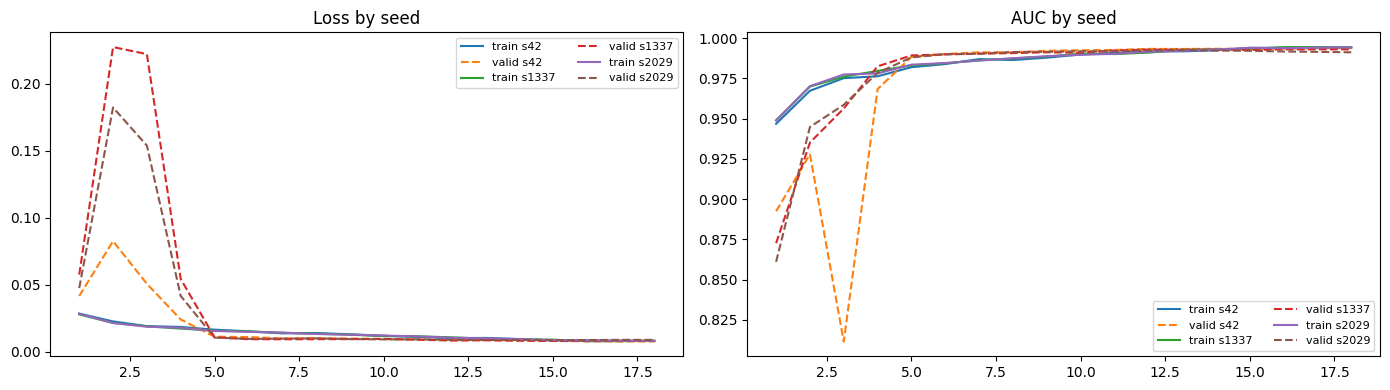

Ensemble validation AUC: 0.9940271764980934
Ensemble test AUC: 0.9905876150748933


In [11]:
seed_runs = []
seed_summaries = []
val_prob_list = []
test_prob_list = []
histories = []

for seed in CFG.ENSEMBLE_SEEDS:
    result = train_one_seed(seed)
    seed_runs.append(result)
    seed_summaries.append(result["summary"])
    val_prob_list.append(result["val_probs"])
    test_prob_list.append(result["test_probs"])
    histories.append(result["history"])

    # free the model object once probabilities are collected
    del result["model"]
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

seed_summary_df = pd.DataFrame(seed_summaries)
display(seed_summary_df)

hist = pd.concat(histories, ignore_index=True)
display(hist.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for seed in CFG.ENSEMBLE_SEEDS:
    h = hist[hist["seed"] == seed]
    axes[0].plot(h["epoch"], h["train_loss"], label=f"train s{seed}")
    axes[0].plot(h["epoch"], h["valid_loss"], linestyle="--", label=f"valid s{seed}")
    axes[1].plot(h["epoch"], h["train_auc"], label=f"train s{seed}")
    axes[1].plot(h["epoch"], h["valid_auc"], linestyle="--", label=f"valid s{seed}")

axes[0].set_title("Loss by seed")
axes[0].legend(ncol=2, fontsize=8)
axes[1].set_title("AUC by seed")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

val_targets = seed_runs[0]["val_targets"]
test_targets = seed_runs[0]["test_targets"]

ensemble_val_probs = np.mean(np.stack(val_prob_list, axis=0), axis=0)
ensemble_test_probs = np.mean(np.stack(test_prob_list, axis=0), axis=0)

print("Ensemble validation AUC:", roc_auc_score(val_targets, ensemble_val_probs))
print("Ensemble test AUC:", roc_auc_score(test_targets, ensemble_test_probs))

np.save(CFG.SAVE_DIR / "ensemble_val_probs.npy", ensemble_val_probs)
np.save(CFG.SAVE_DIR / "ensemble_test_probs.npy", ensemble_test_probs)
np.save(CFG.SAVE_DIR / "val_targets.npy", val_targets)
np.save(CFG.SAVE_DIR / "test_targets.npy", test_targets)
seed_summary_df.to_csv(CFG.SAVE_DIR / "seed_summary.csv", index=False)


In [12]:
def tpr_at_fpr(y_true, y_prob, max_fpr=1e-2):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    valid = np.where(fpr <= max_fpr)[0]
    return float(tpr[valid].max()) if len(valid) else 0.0

def choose_threshold(y_true, y_prob, thresholds=None, objective="f1"):
    if thresholds is None:
        thresholds = CFG.THRESH_GRID

    best_thr = 0.5
    best_score = -np.inf
    rows = []

    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)

        acc = accuracy_score(y_true, pred)
        bal_acc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        spec = tn / (tn + fp + 1e-12)
        youden = rec + spec - 1.0

        row = {
            "threshold": thr,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "precision": prec,
            "recall": rec,
            "specificity": spec,
            "f1": f1,
            "youden_j": youden,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn
        }
        rows.append(row)

        score = row["f1"] if objective == "f1" else row["youden_j"]
        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, pd.DataFrame(rows)

def metric_summary(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    precision = precision_score(y_true, y_pred, zero_division=0)
    npv = tn / (tn + fn + 1e-12)

    summary = {
        "threshold": thr,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "npv": npv,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob),
        "tpr_at_fpr_1e-2": tpr_at_fpr(y_true, y_prob, 1e-2),
        "tpr_at_fpr_1e-3": tpr_at_fpr(y_true, y_prob, 1e-3),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

    report = classification_report(
        y_true, y_pred,
        target_names=["non-lens", "lens"],
        output_dict=True, zero_division=0
    )
    per_class = pd.DataFrame(report).T

    return pd.DataFrame([summary]), per_class, y_pred

best_thr, thr_table = choose_threshold(val_targets, ensemble_val_probs, objective="f1")
display(thr_table.sort_values("f1", ascending=False).head(10))

val_summary, val_per_class, val_preds = metric_summary(val_targets, ensemble_val_probs, thr=best_thr)
print("Chosen threshold from ensembled validation:", best_thr)
display(val_summary)
display(val_per_class)


,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,youden_j,tp,fp,tn,fn
152,0.810,0.982243,0.906395,0.860606,0.820809,0.991980,0.840237,0.812790,142,23,2845,31
151,0.805,0.981256,0.905872,0.845238,0.820809,0.990934,0.832845,0.811744,142,26,2842,31
153,0.815,0.981585,0.897899,0.863354,0.803468,0.992329,0.832335,0.795797,139,22,2846,34
148,0.790,0.980270,0.921644,0.808743,0.855491,0.987796,0.831461,0.843288,148,35,2833,25
150,0.800,0.980270,0.910781,0.822857,0.832370,0.989191,0.827586,0.821561,144,31,2837,29
156,0.830,0.981585,0.884319,0.887417,0.774566,0.994073,0.827160,0.768639,134,17,2851,39
149,0.795,0.979941,0.913322,0.814607,0.838150,0.988494,0.826211,0.826644,145,33,2835,28
155,0.825,0.981256,0.886861,0.876623,0.780347,0.993375,0.825688,0.773722,135,19,2849,38
147,0.785,0.979283,0.921121,0.795699,0.855491,0.986750,0.824513,0.842242,148,38,2830,25
154,0.820,0.980927,0.889402,0.866242,0.786127,0.992678,0.824242,0.778805,136,21,2847,37


Chosen threshold from ensembled validation: 0.8099999999999999


,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn
0,0.81,0.994027,0.925544,0.982243,0.906395,0.860606,0.820809,0.99198,0.840237,0.989221,0.831102,0.830841,0.036339,0.82659,0.606936,142,23,2845,31


,precision,recall,f1-score,support
non-lens,0.989221,0.991980,0.990599,2868.000000
lens,0.860606,0.820809,0.840237,173.000000
accuracy,0.982243,0.982243,0.982243,0.982243
macro avg,0.924914,0.906395,0.915418,3041.000000
weighted avg,0.981904,0.982243,0.982045,3041.000000


,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn
0,0.81,0.990588,0.783103,0.992214,0.932608,0.57047,0.871795,0.993421,0.689655,0.998708,0.701756,0.685887,0.035162,0.897436,0.523077,170,128,19327,25


,precision,recall,f1-score,support
non-lens,0.998708,0.993421,0.996057,19455.000000
lens,0.570470,0.871795,0.689655,195.000000
accuracy,0.992214,0.992214,0.992214,0.992214
macro avg,0.784589,0.932608,0.842856,19650.000000
weighted avg,0.994458,0.992214,0.993017,19650.000000


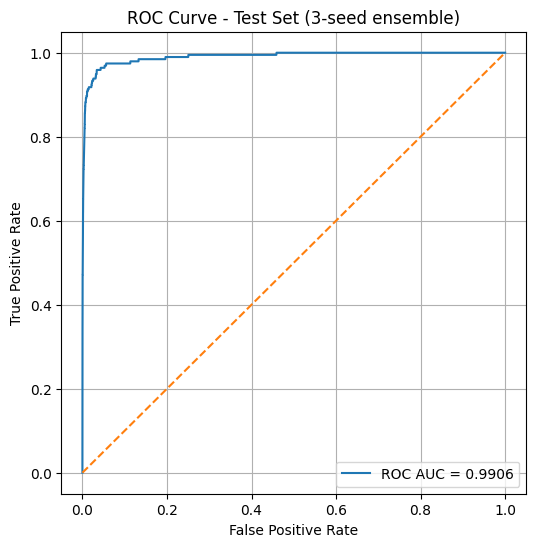

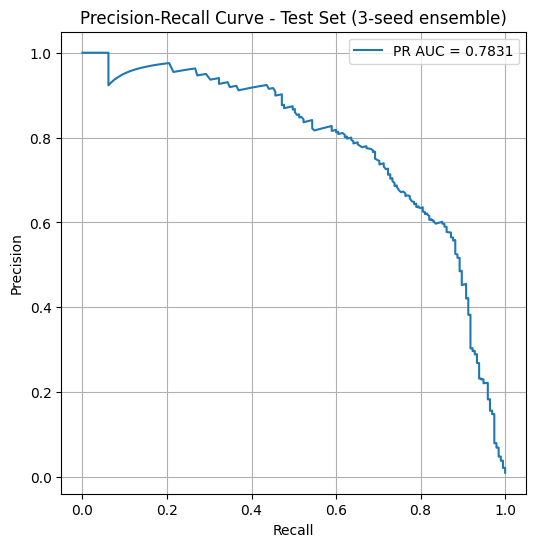

thr=0.300 | TP=190 FP=1890 TN=17565 FN=5 | TPR=0.9744 FPR=0.0971 Precision=0.0913
thr=0.500 | TP=188 FP=905 TN=18550 FN=7 | TPR=0.9641 FPR=0.0465 Precision=0.1720
thr=0.700 | TP=179 FP=331 TN=19124 FN=16 | TPR=0.9179 FPR=0.0170 Precision=0.3510
thr=0.810 | TP=170 FP=128 TN=19327 FN=25 | TPR=0.8718 FPR=0.0066 Precision=0.5705


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,path,target,prob_ensemble,pred_ensemble
0,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,0.872070,1
1,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,0.945312,1
2,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,0.933105,1
3,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,0.822754,1
4,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,0.956543,1


In [13]:
test_summary, test_per_class, test_preds = metric_summary(
    test_targets, ensemble_test_probs, thr=best_thr
)
display(test_summary)
display(test_per_class)

fpr, tpr, _ = roc_curve(test_targets, ensemble_test_probs)
prec_curve, rec_curve, _ = precision_recall_curve(test_targets, ensemble_test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {test_summary.loc[0, 'roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set (3-seed ensemble)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(rec_curve, prec_curve, label=f"PR AUC = {test_summary.loc[0, 'pr_auc']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set (3-seed ensemble)")
plt.legend()
plt.grid(True)
plt.show()

for thr in [0.30, 0.50, 0.70, float(best_thr)]:
    preds = (ensemble_test_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_targets, preds).ravel()
    tpr_ = tp / (tp + fn + 1e-9)
    fpr_ = fp / (fp + tn + 1e-9)
    prec_ = tp / (tp + fp + 1e-9)
    print(
        f"thr={thr:.3f} | TP={tp} FP={fp} TN={tn} FN={fn} | "
        f"TPR={tpr_:.4f} FPR={fpr_:.4f} Precision={prec_:.4f}"
    )

ensemble_outputs = pd.DataFrame({
    "path": test_df["path"],
    "target": test_targets.astype(int),
    "prob_ensemble": ensemble_test_probs,
    "pred_ensemble": test_preds.astype(int),
})
display(ensemble_outputs.head())
ensemble_outputs.to_csv(CFG.SAVE_DIR / "ensemble_test_outputs.csv", index=False)


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# =========================
# CHOOSE WHICH SPLIT TO ANALYZE
# =========================
# set to "test" or "valid"
split_name = "test"

if split_name == "test":
    split_df = test_df.reset_index(drop=True).copy()
    y_true = np.asarray(test_targets).astype(int)
    y_prob = np.asarray(test_probs).astype(float)
elif split_name == "valid":
    split_df = val_df.reset_index(drop=True).copy()
    y_true = np.asarray(val_targets).astype(int)
    y_prob = np.asarray(val_probs).astype(float)
else:
    raise ValueError("split_name must be 'test' or 'valid'")

thr = float(best_thr) if "best_thr" in globals() else 0.5
y_pred = (y_prob >= thr).astype(int)

if len(split_df) != len(y_true):
    raise ValueError(f"Length mismatch: len(split_df)={len(split_df)} vs len(y_true)={len(y_true)}")

analysis_df = split_df.copy()
analysis_df["target"] = y_true
analysis_df["prob"] = y_prob
analysis_df["pred"] = y_pred

def outcome_name(t, p):
    if t == 1 and p == 1:
        return "TP"
    if t == 0 and p == 1:
        return "FP"
    if t == 1 and p == 0:
        return "FN"
    return "TN"

analysis_df["outcome"] = [outcome_name(t, p) for t, p in zip(y_true, y_pred)]
analysis_df["error"] = (analysis_df["target"] != analysis_df["pred"]).astype(int)
analysis_df["confidence"] = np.where(analysis_df["pred"] == 1, analysis_df["prob"], 1.0 - analysis_df["prob"])

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"Split: {split_name}")
print(f"Threshold: {thr:.4f}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

print("\nCounts by outcome:")
print(analysis_df["outcome"].value_counts())

os.makedirs("/kaggle/working/error_analysis", exist_ok=True)
csv_path = f"/kaggle/working/error_analysis/{split_name}_error_analysis.csv"
analysis_df.to_csv(csv_path, index=False)
print(f"\nSaved analysis CSV to: {csv_path}")

display(analysis_df.head())

In [ ]:
import math
import matplotlib.pyplot as plt

def _to_rgb_for_display(x):
    # x expected [3,H,W] in [0,1]
    rgb = np.stack([x[0], x[1], x[2]], axis=-1)
    return np.clip(rgb, 0, 1)

def show_outcome_gallery(
    analysis_df,
    outcome="FP",
    n=12,
    sort_mode="most_confident",
    bands=False,
    save=True,
    figsize_scale=3.6
):
    """
    outcome: TP / FP / FN / TN
    sort_mode:
        - "most_confident"  : strongest examples of that outcome
        - "least_confident" : weakest examples of that outcome
        - "random"          : random examples
    bands:
        - False -> pseudo-RGB
        - True  -> show 3 bands per sample
    """
    sub = analysis_df[analysis_df["outcome"] == outcome].copy()

    if len(sub) == 0:
        print(f"No samples for outcome={outcome}")
        return

    # sensible default ordering
    if sort_mode == "most_confident":
        if outcome in ["FP", "TP"]:
            sub = sub.sort_values("prob", ascending=False)
        else:  # FN, TN
            sub = sub.sort_values("prob", ascending=True)
    elif sort_mode == "least_confident":
        if outcome in ["FP", "TP"]:
            sub = sub.sort_values("prob", ascending=True)
        else:
            sub = sub.sort_values("prob", ascending=False)
    elif sort_mode == "random":
        sub = sub.sample(frac=1.0, random_state=42)
    else:
        raise ValueError("sort_mode must be most_confident / least_confident / random")

    sub = sub.head(min(n, len(sub))).reset_index(drop=True)

    if not bands:
        cols = 4
        rows = math.ceil(len(sub) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(figsize_scale * cols, figsize_scale * rows))
        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, sub.iterrows()):
            x = load_npy(row.path)
            x = astrophysical_stretch(x)
            ax.imshow(_to_rgb_for_display(x))
            ax.set_title(
                f"{row.outcome} | y={int(row.target)} pred={int(row.pred)}\n"
                f"p={row.prob:.3f}"
            )
            ax.axis("off")

        for ax in axes[len(sub):]:
            ax.axis("off")

        plt.suptitle(f"{split_name.upper()} {outcome} ({sort_mode})", fontsize=16)
        plt.tight_layout()
        plt.show()

        if save:
            out_path = f"/kaggle/working/error_analysis/{split_name}_{outcome}_{sort_mode}_rgb.png"
            fig.savefig(out_path, dpi=180, bbox_inches="tight")
            print("Saved:", out_path)

    else:
        rows = len(sub)
        fig, axes = plt.subplots(rows, 3, figsize=(12, 3 * rows))
        if rows == 1:
            axes = np.array([axes])

        for i, (_, row) in enumerate(sub.iterrows()):
            x = load_npy(row.path)
            x = astrophysical_stretch(x)

            for c in range(3):
                axes[i, c].imshow(x[c], cmap="magma")
                axes[i, c].set_title(
                    f"{row.outcome} | band {c}\n"
                    f"y={int(row.target)} pred={int(row.pred)} p={row.prob:.3f}"
                )
                axes[i, c].axis("off")

        plt.suptitle(f"{split_name.upper()} {outcome} bands ({sort_mode})", fontsize=16)
        plt.tight_layout()
        plt.show()

        if save:
            out_path = f"/kaggle/working/error_analysis/{split_name}_{outcome}_{sort_mode}_bands.png"
            fig.savefig(out_path, dpi=180, bbox_inches="tight")
            print("Saved:", out_path)

# =========================
# RUN ALL FOUR OUTCOME GALLERIES
# =========================
for outcome in ["FP", "FN", "TP", "TN"]:
    show_outcome_gallery(
        analysis_df,
        outcome=outcome,
        n=12,
        sort_mode="most_confident",
        bands=False,   # pseudo-RGB
        save=True
    )

# Optional: inspect the hardest mistakes band-by-band
show_outcome_gallery(analysis_df, outcome="FP", n=8, sort_mode="most_confident", bands=True, save=True)
show_outcome_gallery(analysis_df, outcome="FN", n=8, sort_mode="most_confident", bands=True, save=True)

## Mermaid: 3-seed ensemble notebook

```mermaid
flowchart TD
    A[Load .npy cutouts] --> B[Asinh stretch + robust normalization]
    B --> C[Fixed 90:10 stratified split inside train folders]
    C --> D[For each seed: 42, 1337, 2029]
    D --> E[Weighted sampler + identical augmentations]
    E --> F[DensePolarNet-Robust]
    F --> F1[DenseNet-161 small stem]
    F --> F2[Polar branch]
    F --> F3[Radial statistics branch]
    F1 --> G[Fusion head]
    F2 --> G
    F3 --> G
    G --> H[Focal loss + AdamW + Cosine LR + EMA]
    H --> I[D4 TTA predictions per seed]
    I --> J[Average seed probabilities]
    J --> K[Choose threshold on ensembled validation only]
    K --> L[Final test ROC-AUC / PR-AUC / confusion metrics]
```
